In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def alpha_polyprotic_from_H(H, pKa_list):
    """
    Compute the alpha fractions starting from [H+].
    alpha[x] corresponds to the species H_(n-x)A^(x-).
    """
    Ka = 10**(-np.asarray(pKa_list, dtype=float))
    n = len(Ka)

    # cumulative products: prodK[i] = K1*K2*...*Ki
    prodK = np.ones(n + 1)
    for i in range(1, n + 1):
        prodK[i] = prodK[i - 1] * Ka[i - 1]

    # denominator:
    # D = [H]^n + sum_{i=1}^n ( [H]^(n-i) * prod_{j=1}^i K_j )
    D = H**n
    for i in range(1, n + 1):
        D += H**(n - i) * prodK[i]

    alpha = np.zeros(n + 1)
    for x in range(n + 1):
        alpha[x] = H**(n - x) * prodK[x] / D

    return alpha

In [23]:
def alpha_polyprotic(pH, pKa_list):
    """
    Vectorized version over an array of pH values.
    Returns an alpha matrix with shape (n+1, len(pH)).
    """
    pH = np.asarray(pH, dtype=float)
    alpha_all = np.array([
        alpha_polyprotic_from_H(10**(-ph), pKa_list) for ph in pH
    ]).T
    return alpha_all

In [24]:
def calculate_pH_polyprotic_acid(pKa_list, Ca, Kw=1e-14, pH_min=-2, pH_max=16, ngrid=4000):
    """
    Compute the pH of a polyprotic acid solution H_nA
    by numerically solving the charge balance equation:

        [H+] = [OH-] + Ca * sum_x x * alpha_x

    with [OH-] = Kw / [H+]
    """
    pKa_list = np.asarray(pKa_list, dtype=float)
    n = len(pKa_list)

    def f(ph):
        H = 10**(-ph)
        OH = Kw / H
        alpha = alpha_polyprotic_from_H(H, pKa_list)
        negative_charge = Ca * np.sum(np.arange(1, n + 1) * alpha[1:])
        return H - OH - negative_charge

    # search for an interval with a sign change
    grid = np.linspace(pH_min, pH_max, ngrid)
    vals = np.array([f(ph) for ph in grid])

    idx = None
    for i in range(len(grid) - 1):
        if vals[i] == 0:
            return grid[i]
        if vals[i] * vals[i + 1] < 0:
            idx = i
            break

    if idx is None:
        raise ValueError("Could not find a root in the selected pH interval.")

    a = grid[idx]
    b = grid[idx + 1]

    # bisection
    for _ in range(100):
        m = 0.5 * (a + b)
        fm = f(m)
        fa = f(a)

        if abs(fm) < 1e-16:
            return m

        if fa * fm < 0:
            b = m
        else:
            a = m

    return 0.5 * (a + b)

In [28]:
def plot_polyprotic_acid(pKa_list, Ca, pH_min=0, pH_max=14, npoints=1000, Kw=1e-14):
    """
    Plot the logC-pH diagram of a polyprotic acid
    and add the solution pH.
    """
    pKa_list = np.asarray(pKa_list, dtype=float)
    n = len(pKa_list)

    pH = np.linspace(pH_min, pH_max, npoints)
    alpha = alpha_polyprotic(pH, pKa_list)
    C = Ca * alpha

    pH_sol = calculate_pH_polyprotic_acid(pKa_list, Ca, Kw=Kw)
    logH_sol = -pH_sol

    fig, ax = plt.subplots(figsize=(10, 6))

    # species labels
    labels = []
    for x in range(n + 1):
        nH = n - x

        if nH > 1:
            base = f'H{nH}A'
        elif nH == 1:
            base = 'HA'
        else:
            base = 'A'

        if x == 0:
            label = base
        elif x == 1:
            label = base + r'$^-$'
        else:
            label = base + rf'$^{{{x}-}}$'

        labels.append(label)

    # species curves
    for x in range(n + 1):
        ax.plot(pH, np.log10(C[x]), label=labels[x], linewidth=2)

    # water diagonals
    ax.plot(pH, -pH, 'r--', label=r'H$_3$O$^+$')
    ax.plot(pH, pH - 14, 'b--', label=r'OH$^-$')

    # vertical pKa lines
    for pKa in pKa_list:
        ax.axvline(pKa, color='gray', linestyle=':', alpha=0.6)

    # highlight the solution pH on the H3O+ diagonal
    ax.plot(pH_sol, logH_sol, 'o', markersize=8, label=f'solution pH = {pH_sol:.2f}')
    ax.annotate(
        f'pH = {pH_sol:.2f}',
        xy=(pH_sol, logH_sol),
        xytext=(pH_sol + 0.4, logH_sol + 1.0),
        arrowprops=dict(arrowstyle='->')
    )

    ax.set_xlim(pH_min, pH_max)
    ax.set_ylim(-14, 1)
    ax.set_xticks(np.arange(np.floor(pH_min), np.ceil(pH_max) + 1, 1))
    ax.set_yticks(np.arange(-14, 2, 1))
    ax.set_xlabel('pH', fontsize=15)
    ax.set_ylabel('log C', fontsize=15)
    ax.grid(True, alpha=0.3)
    ax.legend()

    return fig, ax, pH_sol

## Example 1: HCN 1e-4 M (pKa = 9.4)

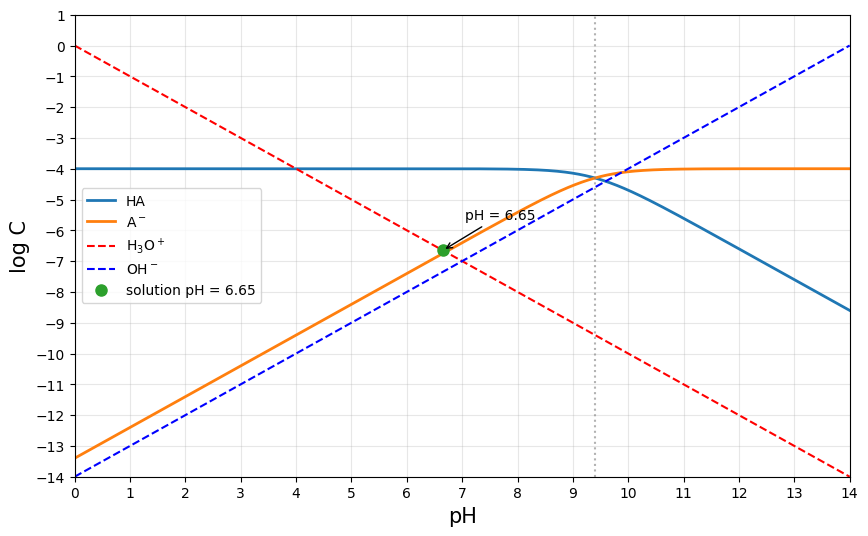

pH  = 6.652


In [32]:
fig, ax, pH_sol  = plot_polyprotic_acid([9.4], 1e-4)
plt.show()

print(f"pH  = {pH_sol:.3f}")

In [ ]:
## Example 2: 

## Example 3: H3PO4 0.1M (pKa1 = 2.15; pKa2 = 7.14; pKa3 = 12.4)

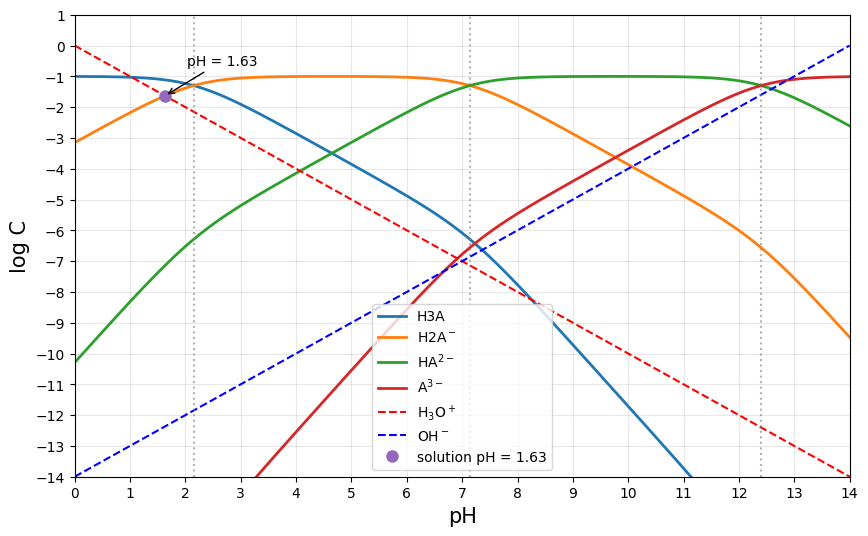

pH  = 1.633


In [33]:
fig, ax, pH_sol =  plot_polyprotic_acid([2.15, 7.14, 12.4], 0.1)
plt.show()

print(f"pH  = {pH_sol:.3f}")